In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
#Code RFM analysis
# Load datasets
customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
tickets = pd.read_csv("data/support_tickets.csv")
web_events = pd.read_csv("data/web_events_snapshot.csv")
labels = pd.read_csv("data/churn_labels.csv")
interventions = pd.read_csv("data/intervention_history.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support Tickets:", tickets.shape)
print("Web Events:", web_events.shape)
print("Churn Labels:", labels.shape)
print("Interventions:", interventions.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support Tickets: (1921, 8)
Web Events: (2400, 10)
Churn Labels: (2400, 4)
Interventions: (2400, 5)


In [2]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web_events": web_events,
    "labels": labels,
    "interventions": interventions
}

for name, df in datasets.items():
    print("="*60)
    print(name.upper())
    print(df.info())
    print(df.head())

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None
  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001   4/24/2024    Tier 1     18-24           Instagram   
1   CUST00002    6/1/2025    Tier 2     25-34         Marketplace   
2   CUST00003    3/8/2025    Tier 1     25-34          Influencer   
3   CUST00004   4/15/2

In [5]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)

rfm = orders.groupby("customer_id").agg(
    recency=("order_date",
             lambda x: (snapshot_date - x.max()).days),

    frequency=("order_id", "nunique"),

    monetary=("gross_amount", "sum")
).reset_index()

rfm.head()

,customer_id,recency,frequency,monetary
0,CUST00001,168,6,2955.57
1,CUST00002,35,3,1713.10
2,CUST00003,232,1,649.98
3,CUST00004,192,1,1604.04
4,CUST00005,11,6,3910.43


In [6]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["RFM_score"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

In [7]:
support_features = (
    tickets.groupby("customer_id")
    .agg(
        support_ticket_count=("ticket_id", "count")
    )
    .reset_index()
)

rfm = rfm.merge(
    support_features,
    on="customer_id",
    how="left"
)

rfm["support_ticket_count"] = (
    rfm["support_ticket_count"]
    .fillna(0)
)

In [11]:
import pandas as pd
import numpy as np

# --- RFM Calculation and Feature Engineering ---

# Ensure orders, labels, and tickets DataFrames are available in the global scope.
# These DataFrames are expected to be loaded by previous cells (e.g., 785702b5).
# Creating copies to prevent unintended modification of global DataFrames.
orders = globals().get('orders', pd.DataFrame()).copy()
labels = globals().get('labels', pd.DataFrame()).copy()
tickets = globals().get('tickets', pd.DataFrame()).copy()

# Convert 'order_date' to datetime and define snapshot date
orders["order_date"] = pd.to_datetime(orders["order_date"])
snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)

# Aggregate RFM features
rfm = orders.groupby("customer_id").agg(
    recency=("order_date",
             lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("gross_amount", "sum")
).reset_index()

print("rfm DataFrame created successfully.")

# 1. Calculate RFM Scores (R_score, F_score, M_score) using quantiles
# Recency: smaller is better (higher score)
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop').astype(int)

# Frequency and Monetary: larger is better (higher score)
rfm['F_score'] = pd.qcut(rfm['frequency'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)

# 2. Calculate refund_rate and merge into rfm
orders_source = orders.copy()
if 'is_refunded' not in orders_source.columns:
    if 'returned' in orders_source.columns:
        orders_source['is_refunded'] = (orders_source['returned'] > 0).astype(int)
    else:
        orders_source['is_refunded'] = 0
        print("Warning: Neither 'is_refunded' nor 'returned' column found in 'orders'. Assuming 0 refund rate for all orders for calculation.")

customer_refund_rate = orders_source.groupby('customer_id')['is_refunded'].mean().reset_index()
customer_refund_rate.rename(columns={'is_refunded': 'refund_rate'}, inplace=True)
rfm = rfm.merge(customer_refund_rate, on='customer_id', how='left')
rfm['refund_rate'].fillna(0, inplace=True) # Customers with no orders or no refunds have 0 refund rate

# 3. Calculate support_ticket_count and merge into rfm
tickets_df = tickets.copy()
if not tickets_df.empty and 'customer_id' in tickets_df.columns:
    customer_ticket_count = tickets_df.groupby('customer_id').size().reset_index(name='support_ticket_count')
    rfm = rfm.merge(customer_ticket_count, on='customer_id', how='left')
    rfm['support_ticket_count'].fillna(0, inplace=True) # Customers with no tickets have 0 count
else:
    print("Warning: 'tickets' DataFrame is empty or missing 'customer_id'. 'support_ticket_count' will be set to 0 for all customers.")
    rfm['support_ticket_count'] = 0

# --- End of RFM Calculation and Feature Engineering ---

# Define the segment assignment function
def assign_segment(row):
    r_score = row.get("R_score", 0)
    f_score = row.get("F_score", 0)
    m_score = row.get("M_score", 0)
    recency = row.get("recency", float('inf'))
    monetary = row.get("monetary", 0)
    refund_rate = row.get("refund_rate", 0)
    support_ticket_count = row.get("support_ticket_count", 0)

    # Calculate median monetary value, ensuring 'monetary' column exists
    monetary_median = rfm["monetary"].median() if "monetary" in rfm.columns else 0

    if (
        r_score >= 4 and
        f_score >= 4 and
        m_score >= 4
    ):
        return "Champions"

    elif (
        f_score >= 4 and
        r_score >= 3
    ):
        return "Loyal Customers"

    elif (
        r_score >= 4 and
        f_score <= 2 # Using F_score for consistency
    ):
        return "New Customers"

    elif (
        recency > 90 and
        monetary > monetary_median
    ):
        return "At Risk"

    elif (
        refund_rate > 0.30
    ):
        return "Discount Sensitive"

    elif (
        support_ticket_count >= 3 and
        monetary > monetary_median
    ):
        return "High Value Unhappy"

    else:
        return "Dormant Customers"

# Apply the segment assignment function
rfm["segment_name"] = rfm.apply(
    assign_segment,
    axis=1
)

print(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'refund_rate', 'support_ticket_count', 'segment_name']].head())
print("\nSegment distribution:")
print(rfm['segment_name'].value_counts())

rfm DataFrame created successfully.


C:\Users\Admin\AppData\Local\Temp\ipykernel_1908\4123084001.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rfm['refund_rate'].fillna(0, inplace=True) # Customers with no orders or no refunds have 0 refund rate
C:\Users\Admin\AppData\Local\Temp\ipykernel_1908\4123084001.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

  customer_id  recency  frequency  monetary  R_score  F_score  M_score  \
0   CUST00001      168          6   2955.57        2        3        3   
1   CUST00002       35          3   1713.10        3        2        2   
2   CUST00003      232          1    649.98        1        1        1   
3   CUST00004      192          1   1604.04        1        1        2   
4   CUST00005       11          6   3910.43        4        3        3   

   refund_rate  support_ticket_count       segment_name  
0     0.166667                   2.0            At Risk  
1     0.000000                   1.0  Dormant Customers  
2     0.000000                   0.0  Dormant Customers  
3     0.000000                   0.0  Dormant Customers  
4     0.000000                   1.0  Dormant Customers  

Segment distribution:
segment_name
Dormant Customers     1238
At Risk                354
New Customers          305
Loyal Customers        206
Discount Sensitive     144
Champions              135
High Valu

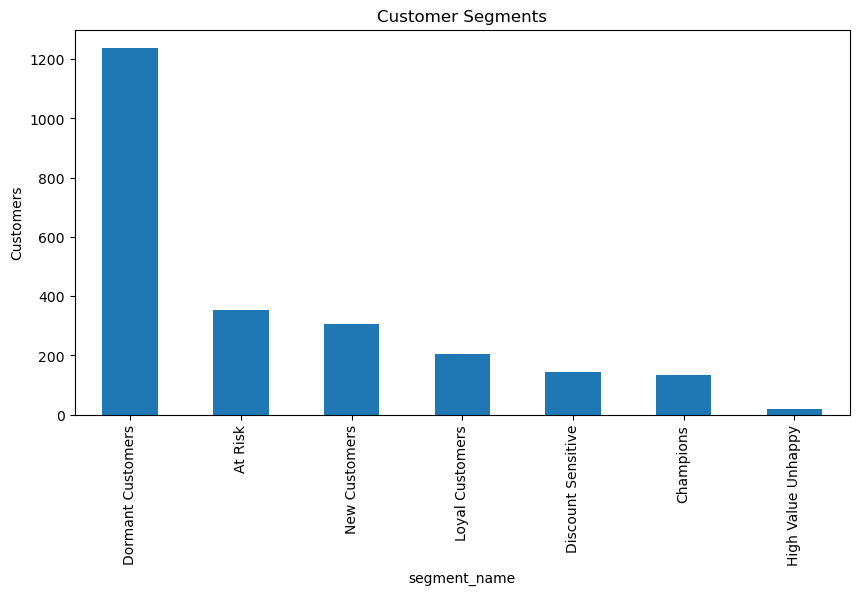

In [12]:
segment_counts = (
    rfm["segment_name"]
    .value_counts()
)

plt.figure(figsize=(10,5))
segment_counts.plot(kind="bar")
plt.title("Customer Segments")
plt.ylabel("Customers")
plt.show()

In [13]:
segment_summary = (
    rfm.groupby("segment_name")
    .agg(
        customers=("customer_id","count"),
        avg_recency=("recency","mean"),
        avg_frequency=("frequency","mean"),
        avg_monetary=("monetary","mean"),
        avg_refund_rate=("refund_rate","mean"),
        avg_tickets=("support_ticket_count","mean")
    )
    .round(2)
)

segment_summary

,customers,avg_recency,avg_frequency,avg_monetary,avg_refund_rate,avg_tickets
segment_name,,,,,,
At Risk,354,202.29,5.29,4282.69,0.06,1.24
Champions,135,11.23,9.00,6741.68,0.07,1.75
Discount Sensitive,144,124.15,2.45,1713.55,0.60,1.22
Dormant Customers,1238,123.16,3.07,2163.77,0.02,0.48
High Value Unhappy,18,45.67,6.39,4821.55,0.11,3.17
Loyal Customers,206,38.18,8.39,6397.69,0.06,1.55
New Customers,305,11.67,3.03,2259.91,0.06,0.32


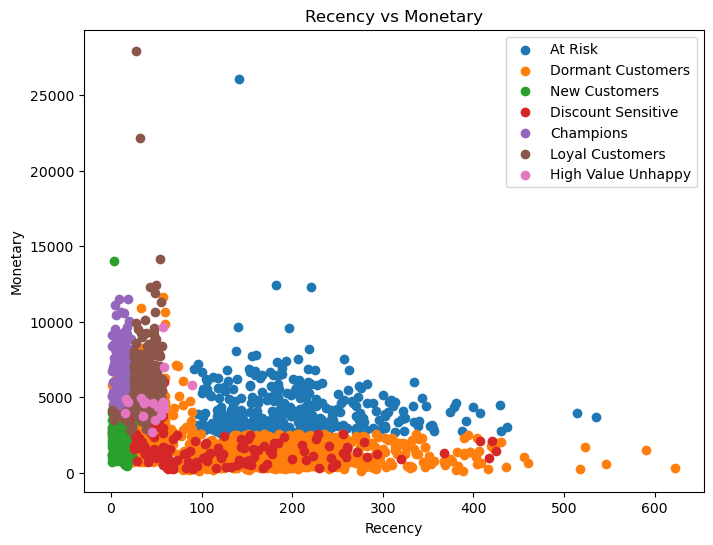

In [14]:
plt.figure(figsize=(8,6))

for segment in rfm["segment_name"].unique():

    temp = rfm[
        rfm["segment_name"] == segment
    ]

    plt.scatter(
        temp["recency"],
        temp["monetary"],
        label=segment
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend()
plt.title("Recency vs Monetary")
plt.show()

In [17]:
final_segments = rfm[
    [
        "customer_id",
        "segment_name",
        "recency",
        "frequency",
        "monetary",
        "support_ticket_count",
        "refund_rate"
    ]
]

final_segments.to_csv(
    "segments.csv",
    index=False
)

print("segments.csv saved")

segments.csv saved


In [20]:
manual_review = rfm[
    (
        (rfm["monetary"] >
         rfm["monetary"].quantile(0.75))
        &
        (rfm["support_ticket_count"] >= 2)
    )
    |
    (
        (rfm["refund_rate"] > 0.25)
    )
].copy()

manual_review = manual_review.head(10)

manual_review[
    [
        "customer_id",
        "segment_name",
        "recency",
        "frequency",
        "monetary",
        "support_ticket_count",
        "refund_rate"
    ]
]

,customer_id,segment_name,recency,frequency,monetary,support_ticket_count,refund_rate
8,CUST00009,Discount Sensitive,29,2,803.99,0.0,0.500000
13,CUST00014,Champions,1,13,9108.63,2.0,0.000000
24,CUST00025,At Risk,226,7,4868.86,3.0,0.000000
25,CUST00026,Discount Sensitive,41,4,4521.43,1.0,0.500000
26,CUST00027,New Customers,15,2,2666.00,1.0,0.500000
32,CUST00033,Discount Sensitive,15,6,3548.90,2.0,0.333333
41,CUST00042,Loyal Customers,46,10,7919.28,6.0,0.200000
48,CUST00049,Discount Sensitive,39,2,1172.61,0.0,0.500000
50,CUST00051,At Risk,271,4,4444.30,2.0,0.000000
51,CUST00052,At Risk,116,3,2807.14,1.0,0.333333
